In [1]:
%load_ext src.agent.magic

DS Agent magic loaded.  Use %agent <query> to generate cells.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

In [3]:
df = pd.read_csv('../data/churn.csv')
print(df.shape)
print(df.dtypes)

(300, 11)
customer_id          object
age                 float64
tenure_months         int64
contract_type        object
internet_service     object
monthly_charges     float64
total_charges       float64
support_calls         int64
late_payments         int64
payment_method       object
churn                 int64
dtype: object


In [4]:
df.head()

,customer_id,age,tenure_months,contract_type,internet_service,monthly_charges,total_charges,support_calls,late_payments,payment_method,churn
0,C0001,58.0,14,Month-to-month,DSL,40.09,554.88,8,0,Mailed check,1
1,C0002,56.0,3,One year,Fiber optic,NaN,264.49,6,1,Mailed check,0
2,C0003,69.0,20,One year,DSL,33.99,723.47,1,3,Bank transfer,0
3,C0004,20.0,58,Month-to-month,No,NaN,3124.03,8,2,Electronic check,0
4,C0005,32.0,37,Two year,No,97.98,3585.17,5,1,Electronic check,0


In [5]:
print(f"Churn rate: {df['churn'].mean():.1%}")
missing = df.isnull().sum()
print('Missing values:')
print(missing[missing > 0])

Churn rate: 42.7%
Missing values:
age                12
monthly_charges    11
dtype: int64


## Ask the agent

Run the cells above first, then use `%agent` — the generated code appears as the next cell ready to execute.

```python
%agent plot churn rate by contract type as a bar chart
%agent write code to train a binary classification model using only age, support_calls, late_payments, monthly_charges. Fill in NA with zeros if there are any
%agent show a ROC curve for the model
```

In [6]:
%agent plot churn rate by contract type as a bar chart

🤖 **Agent** — *plot churn rate by contract type as a bar chart*

✅ Done

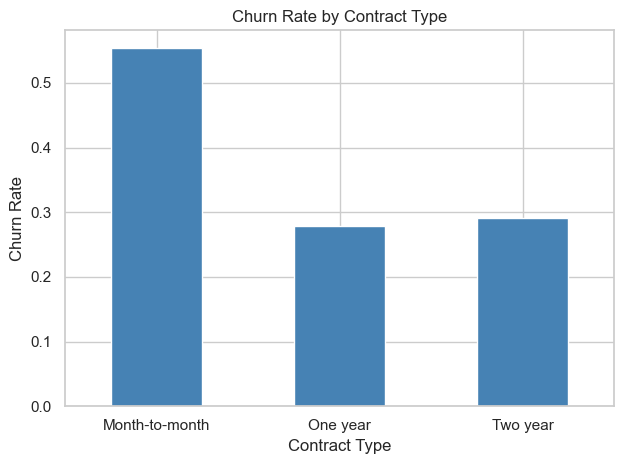

In [7]:
churn_by_contract_type = df.groupby('contract_type')['churn'].mean()

fig, ax = plt.subplots()
churn_by_contract_type.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate')
ax.set_title('Churn Rate by Contract Type')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

In [8]:
%agent write code to train a binary classification model using only age, support_calls, late_payments, monthly_charges. Fill in NA with zeros if there are any

🤖 **Agent** — *write code to train a binary classification model using only age, support_calls, late_payments, monthly_charges. Fill in NA with zeros if there are any*

✅ Done

In [13]:
import sklearn.model_selection
import sklearn.linear_model
import sklearn.metrics

# Fill missing values with zeros
df['age'] = df['age'].fillna(0)
df['monthly_charges'] = df['monthly_charges'].fillna(0)

# Split data into features and target
X = df[['age', 'support_calls', 'late_payments', 'monthly_charges']]
y = df['churn']

# Split into training and testing sets
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

# Train Logistic Regression model
model = sklearn.linear_model.LogisticRegression()
model.fit(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)
accuracy = sklearn.metrics.accuracy_score(y_test, y_pred)

print(f"Model accuracy: {accuracy:.2f}")

Model accuracy: 0.67


In [10]:
%agent now train a different model (regression) to predict late payments

🤖 **Agent** — *now train a different model (regression) to predict late payments*

✅ Done

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Define features and target
X = df[['age', 'support_calls', 'monthly_charges']]
y = df['late_payments']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression model
regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

# Make predictions
y_pred = regression_model.predict(X_test)

# Calculate R-squared score
r_squared = r2_score(y_test, y_pred)

r_squared

-0.008993647837276741

In [12]:
%agent for the churn classifier, write code to see confusion matrix

🤖 **Agent** — *for the churn classifier, write code to see confusion matrix*

✅ Done

AttributeError: 'Axes' object has no attribute 'xlabel'

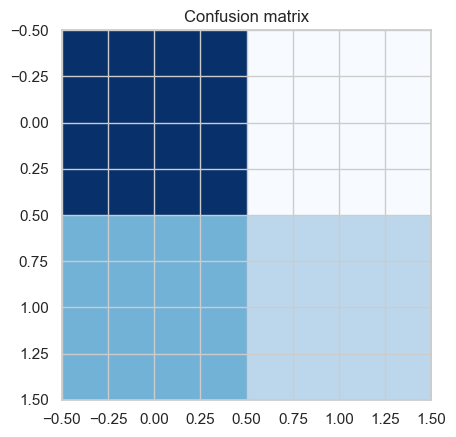

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
fig, ax = plt.subplots()
ax.imshow(cm, interpolation='nearest', cmap='Blues')
ax.title.set_text('Confusion matrix')
ax.xlabel('Predicted')
ax.ylabel('True')
ax.xaxis.set_ticklabels(['No', 'Yes'])
ax.yaxis.set_ticklabels(['No', 'Yes'])
plt.tight_layout()
plt.show()